In [6]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
#import PCGP.gpytorch_tools as gt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormaps
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from types import SimpleNamespace


plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()

save_dir = os.path.join(base_dir, "../graphs")
data_dir_ex2 = os.path.join(base_dir,  "../Experiment1_Tripendulum", "optimisation", "output_data")
sim_data_dir_ex2 = os.path.join(base_dir,  "../Experiment1_Tripendulum", "input_data")
graph_abstract = os.path.join(base_dir,    "output")

def load_data(fpath):
    """Load a results .npz file and return its arrays as torch tensors in a namespace."""
    raw = np.load(fpath, allow_pickle = True)
    ns = SimpleNamespace()
    for key in raw:
        try:
            setattr(ns, key, torch.tensor(raw[key]))
        except Exception:
            setattr(ns, key, raw[key])
    return ns

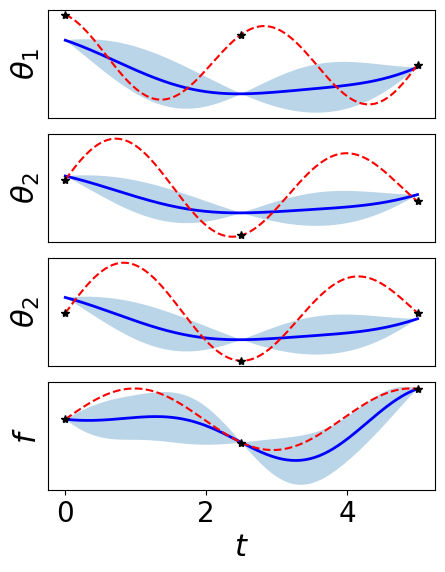

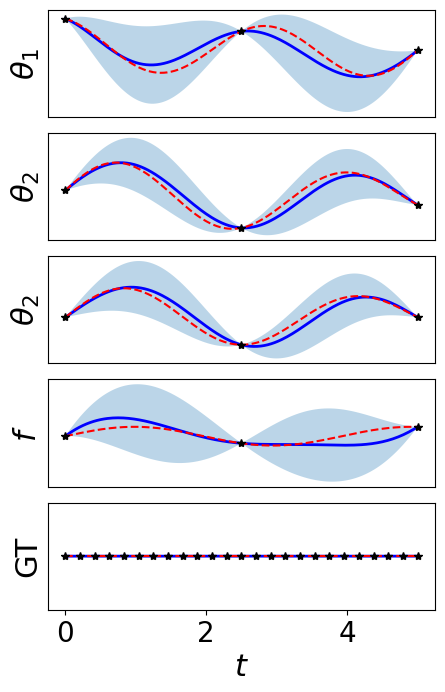

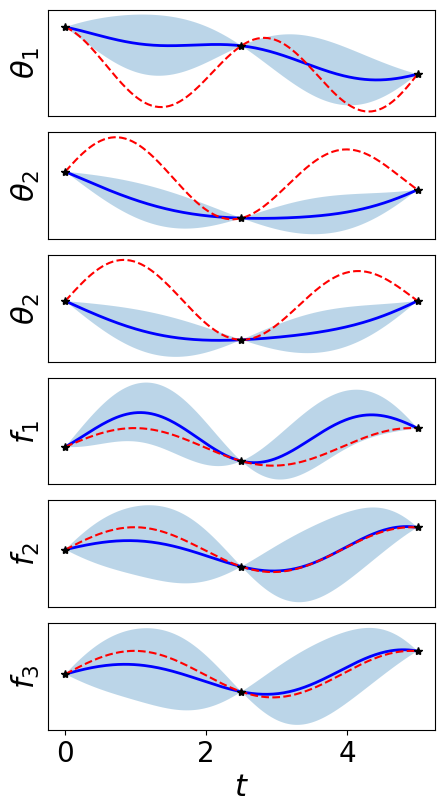

<Figure size 1200x80 with 0 Axes>

In [41]:
task_labels = {"NSB": [r"$\theta_1$", r"$\theta_2$", r"$\theta_2$", r"$f$"]  ,
               "GT": [r"$\theta_1$", r"$\theta_2$", r"$\theta_2$", r"$f$", r"$\xi_{GT}$"],
               "PIGP": [r"$\theta_1$", r"$\theta_2$", r"$\theta_2$", r"$f_1$", r"$f_2$", r"$f_3$", ]}
modes = [ "NSB", "GT", "PIGP"]

npoints = 3
run = 3
sigma = 0.001
n_tasks = {"NSB":4, "GT":5, "PIGP":6}
mode_paths = {"NSB": os.path.join(graph_abstract, f"reference_n%i.npz"%npoints),
              "GT": os.path.join(graph_abstract, f"GT_n%i.npz"%npoints),
              "PIGP": os.path.join(graph_abstract, f"PIGP_n%i.npz"%npoints),}
for mode in modes:
    data = load_data(mode_paths[mode])

    num_tasks = n_tasks[mode]
    height_per_axis = 1.2
    bottom_margin = 0.8     # space for xlabel
    top_margin = 0.3
    hspace = 0.15
    
    fig_height = (
        num_tasks * height_per_axis
        + bottom_margin
        + top_margin
    )
    
    fig, ax = plt.subplots(
        num_tasks,
        1,
        sharex=True,
        figsize=(5, fig_height),
        gridspec_kw={"hspace": hspace}
    )

    for i in range(num_tasks):
                ax[i].plot(data.test_x[data.test_x[:,-1]==i, 0], data.mean[data.test_x[:,-1]==i], 'b', linewidth=2, label = "Mean")
                ax[i].fill_between(data.test_x[data.test_x[:,-1]==i, 0], data.lower[data.test_x[:,-1]==i], data.upper[data.test_x[:,-1]==i], alpha=0.3, label = r"""$\pm 2\sigma$ uncertainty""")
                ax[i].plot(data.test_x[data.test_x[:,-1]==i,0], data.test_y[data.test_x[:,-1]==i], "r--", label = "Truth")
                ax[i].plot(data.train_x[data.train_x[:,-1]==i,0], data.train_y[data.train_x[:,-1]==i], 'k*', label = "Training data")
                if mode == "GT":
                        ax[i].set_ylabel(task_labels[mode][i] if i < 4 else f"GT", fontsize=22)
                        ax[-1].set_ylim([-0.02, +0.02])
                else:
                    ax[i].set_ylabel(task_labels[mode][i], fontsize=22)
                if i < num_tasks - 1:
                    ax[i].tick_params(labelbottom=False, bottom = False, labelsize=20)
                    ax[i].set_yticks([])
                else:
                    if mode == "GT":
                        ax[i].set_ylim((-1, 1))
                    ax[i].set_xlabel(r"$t$", fontsize=22)
                    ax[i].tick_params(labelsize=20)
                   
                    ax[i].set_yticks([])
                    
    fig.subplots_adjust(
    bottom=bottom_margin / fig_height,
    top=1 - top_margin / fig_height
)
    plt.savefig(os.path.join(save_dir, "graphical_abstract_%s.pdf"%mode), bbox_inches='tight')


from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# proxy artists: fresh objects, not the ones already owned by the per-mode figures
legend_handles = [
    Line2D([], [], color='b', linewidth=2,               label="Mean"),
    Patch(facecolor='C0', alpha=0.3,                     label=r"$\pm 2\sigma$ confidence"),
    Line2D([], [], color='r', linestyle='--',            label="Truth"),
    Line2D([], [], color='k', linestyle='none', marker='*', markersize=12,
                                                         label="Training data"),
]

fig_leg = plt.figure(figsize=(12, 0.8))
fig_leg.legend(handles=legend_handles, loc='center', ncol=1,
               frameon=False, fontsize=22, handlelength=2.0, columnspacing=1.5)
fig_leg.savefig(os.path.join(save_dir, "graphical_abstract_legend.pdf"),
                 bbox_inches='tight')




# Error metric: absolute value of MAP parameter estimate error relative to parameter size, one shot

Parameter 1
Parameter 2
Ratio


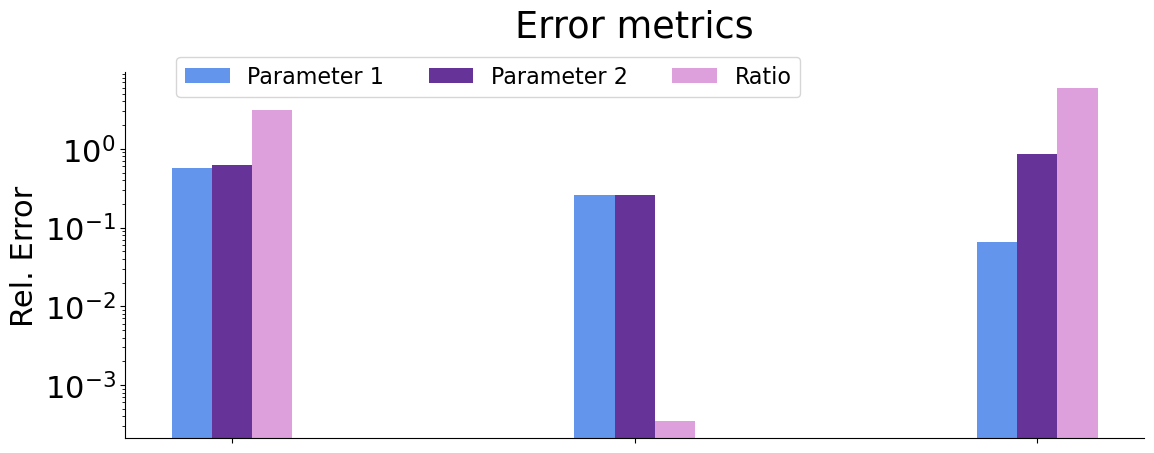

In [37]:
sigma = 0.01
npoints = 3
modes = ["NSB", "GT", "PIGP"]
num_tasks_list = [5, 6, 4]  # given
run = 0
# data_mode for GT/PIGP (current output_data/ folder structure), one of:
#   "standard", "extra_npoints", "extra_npoints_extra_sigma", "known_u", "known_u_known_sigma"
data_mode = {"GT":"extra_npoints_extra_sigma", "PIGP":"standard"}

means = {}
stds = {}
delta1_mean, delta2_mean, delta3_mean = [],[],[]
delta1_std, delta2_std, delta3_std = [],[],[]
delta_l, delta_g, delta_r = {}, {}, {}
for mode in modes:
    if mode != "NSB":
        fpath = os.path.join(data_dir_ex2, data_mode[mode], f"Ex1_{mode}_n{npoints}_sigma{sigma:.3f}_{run}.npz")
    else:
        fpath = os.path.join(graph_abstract, f"reference_n%i.npz"%(npoints))
    data_ex2 = load_data(fpath)
    lp, tp = data_ex2.learned_parameters, data_ex2.true_parameters
    delta_l[mode] = abs(lp[0]-tp[0])/tp[0]
    delta_g[mode] = abs(lp[1]-tp[1])/tp[1]
    delta_r[mode] = abs(lp[0]/lp[1]-tp[0]/tp[1])/(tp[0]/tp[1])
    
   
    
means[r"""Parameter 1"""] = torch.Tensor(delta1_mean)
means[r"""Parameter 2"""] = torch.Tensor(delta2_mean)
means[r"""Ratio"""] = torch.Tensor(delta3_mean)
stds[r"""Parameter 1"""] = torch.Tensor(delta1_std)
stds[r"""Parameter 2"""] = torch.Tensor(delta2_std)
stds[r"""Ratio"""] = torch.Tensor(delta3_std)


#formatting
metrics = list(means.keys())  # ["Δℓ", "Δg", "Δ(ℓ/g)"]
x = np.arange(len(modes))    # groups = modes
width = 0.1
colors = ["cornflowerblue", "rebeccapurple", "plum"]
fig, ax = plt.subplots(figsize=(12, 5))

metrics = ["""Parameter 1""", """Parameter 2""", """Ratio"""]
vals = {}
vals["""Parameter 1"""] = [delta_l[mode] for mode in modes]
vals["""Parameter 2"""] = [delta_g[mode] for mode in modes]
vals["""Ratio"""] = [delta_r[mode] for mode in modes]
for i, metric in enumerate(metrics):
    print(metric)
    values = vals[metric]
    offset = (i - 1) * width   # center the 3 bars
    rects = ax.bar(x + offset, values, width, label=metric, color = colors[i])
    plt.legend()
    #ax.errorbar(x+offset, values, yerr = err,)# marker = "", linestyle = "none")
    #ax.bar_label(rects, padding=3, fontsize=10)

#formatting
ax.set_xticks(x)
ax.set_xticklabels([])
ax.set_title("Error metrics", pad = 25)
ax.set_yscale("log")
ax.set_ylabel("Rel. Error")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(ncols = 3, fontsize = 16, loc = (.05, 0.93))
plt.tight_layout(h_pad = 2)

plt.savefig(os.path.join(save_dir, "graphical_abstract_error.pdf") ,bbox_inches='tight')